# NYC Restaurant Intelligence Platform — Market Overview
## Notebook 02: Borough x Cuisine Market Landscape

**Input**: the cleaned tables in `data/cleaned/`, produced by `01_data_quality_check.ipynb`
**Output**: charts in `reports/figures/`, plus the findings below

### Questions this notebook answers
1. How large is each borough's restaurant market, by count and by population density?
2. What does the citywide cuisine landscape look like?
3. How does cuisine composition differ between boroughs?
4. Which borough-cuisine combinations are notably under-supplied — i.e. potential market gaps?

> **Grain reminder**: this notebook uses `restaurants.csv` (one row per restaurant)
> throughout, never the raw inspection extract. See Notebook 01 — counting rows in the
> violation-level table overstates restaurant counts by roughly 10x.

In [1]:
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)

PROJ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CLEANED = PROJ / "data" / "cleaned"
FIGURES = PROJ / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

restaurants = pd.read_csv(CLEANED / "restaurants.csv")
print(f"Loaded {len(restaurants):,} restaurants")

Loaded 31,222 restaurants


### Chart configuration

Colour follows three rules:
- **Magnitude** -> a single blue ramp, light = low, dark = high
- **Deviation with a meaningful centre** -> a blue/red diverging scale with a neutral
  grey midpoint anchoring "on par"
- No rainbow scales, and no dual-axis charts — two measures on different scales get two
  charts, because a shared axis invents a crossover point that means nothing

In [2]:
# Sequential blue: encodes magnitude
SEQ_BLUE = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
CMAP_SEQ = LinearSegmentedColormap.from_list("seq_blue", SEQ_BLUE)

# Diverging blue/red with a grey midpoint: encodes above/below a baseline
DIVERGING = ["#8f2020", "#d03b3b", "#e88b8b", "#f0efec", "#86b6ef", "#2a78d6", "#0d366b"]
CMAP_DIV = LinearSegmentedColormap.from_list("div_rb", DIVERGING)

BLUE = "#2a78d6"
INK = "#0b0b0b"
INK_SOFT = "#52514e"
GRID = "#e5e4e0"

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "axes.unicode_minus": False,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_SOFT, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlepad": 14,
    "axes.labelsize": 10, "axes.grid": False,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False,
})


def strip_axes(ax, keep=("left", "bottom")):
    """Drop chart borders so grid and axes recede behind the data."""
    for side in ["top", "right", "left", "bottom"]:
        if side not in keep:
            ax.spines[side].set_visible(False)
    ax.tick_params(length=0)


print("Chart configuration ready")

Chart configuration ready


## 1. Analytical scope

Any share analysis lives or dies by its denominator. Two groups of records are excluded,
and **the size of each exclusion is stated openly** — without it a reader cannot judge
how much the shares can be trusted.

In [3]:
n_total = len(restaurants)

excl_boro = restaurants["boro"] == "Unknown"
excl_cuisine = restaurants["cuisine"].isin(["UNKNOWN", "OTHER"])

scope = pd.DataFrame([
    {"scope": "All restaurants", "restaurants": n_total, "pct": 100.0},
    {"scope": "Excluded: unknown borough", "restaurants": int(excl_boro.sum()),
     "pct": round(excl_boro.sum() / n_total * 100, 2)},
    {"scope": "Excluded: cuisine UNKNOWN / OTHER", "restaurants": int(excl_cuisine.sum()),
     "pct": round(excl_cuisine.sum() / n_total * 100, 2)},
])

# Borough size analysis: only drop unknown boroughs (missing cuisine is irrelevant here)
boro_scope = restaurants[~excl_boro].copy()
# Cuisine composition analysis: drop both
mix = restaurants[~excl_boro & ~excl_cuisine].copy()

scope.loc[len(scope)] = {"scope": "-> cuisine analysis base", "restaurants": len(mix),
                         "pct": round(len(mix) / n_total * 100, 2)}
display(scope)

print(f"Borough-size base:     {len(boro_scope):,} restaurants")
print(f"Cuisine-analysis base: {len(mix):,} restaurants ({len(mix)/n_total:.1%})")
print("\nNote: the 3,643 restaurants without a cuisine label are 11.7% of the total.")
print("Every cuisine share below is out of 26,957, not 31,222 — quote it accordingly.")

,scope,restaurants,pct
0,All restaurants,31222,100.00
1,Excluded: unknown borough,85,0.27
2,Excluded: cuisine UNKNOWN / OTHER,4232,13.55
3,-> cuisine analysis base,26957,86.34


Borough-size base:     31,137 restaurants
Cuisine-analysis base: 26,957 restaurants (86.3%)

Note: the 3,643 restaurants without a cuisine label are 11.7% of the total.
Every cuisine share below is out of 26,957, not 31,222 — quote it accordingly.


## 2. Market size by borough

Store count and population density are measured on different scales, so they get **two
charts side by side** rather than one chart with two y-axes.

Population is an **external constant** from the 2020 US Census, not derived from this dataset.

In [4]:
# Source: U.S. Census Bureau, 2020 Decennial Census (NYC borough population)
POPULATION_2020 = {
    "Manhattan": 1_694_251,
    "Brooklyn": 2_736_074,
    "Queens": 2_405_464,
    "Bronx": 1_472_654,
    "Staten Island": 495_747,
}

boro_stats = (
    boro_scope["boro"].value_counts().rename("restaurants").to_frame()
    .join(pd.Series(POPULATION_2020, name="population"))
)
boro_stats["per_10k"] = (boro_stats["restaurants"] / boro_stats["population"] * 10000).round(1)
boro_stats["share_pct"] = (boro_stats["restaurants"] / boro_stats["restaurants"].sum() * 100).round(1)
boro_stats = boro_stats.sort_values("restaurants", ascending=False)

city_avg = boro_stats["restaurants"].sum() / boro_stats["population"].sum() * 10000
display(boro_stats)
print(f"Citywide density: {city_avg:.1f} restaurants per 10,000 residents")

,restaurants,population,per_10k,share_pct
boro,,,,
Manhattan,12446,1694251,73.5,40.0
Brooklyn,7945,2736074,29.0,25.5
Queens,7003,2405464,29.1,22.5
Bronx,2632,1472654,17.9,8.5
Staten Island,1111,495747,22.4,3.6


Citywide density: 35.4 restaurants per 10,000 residents


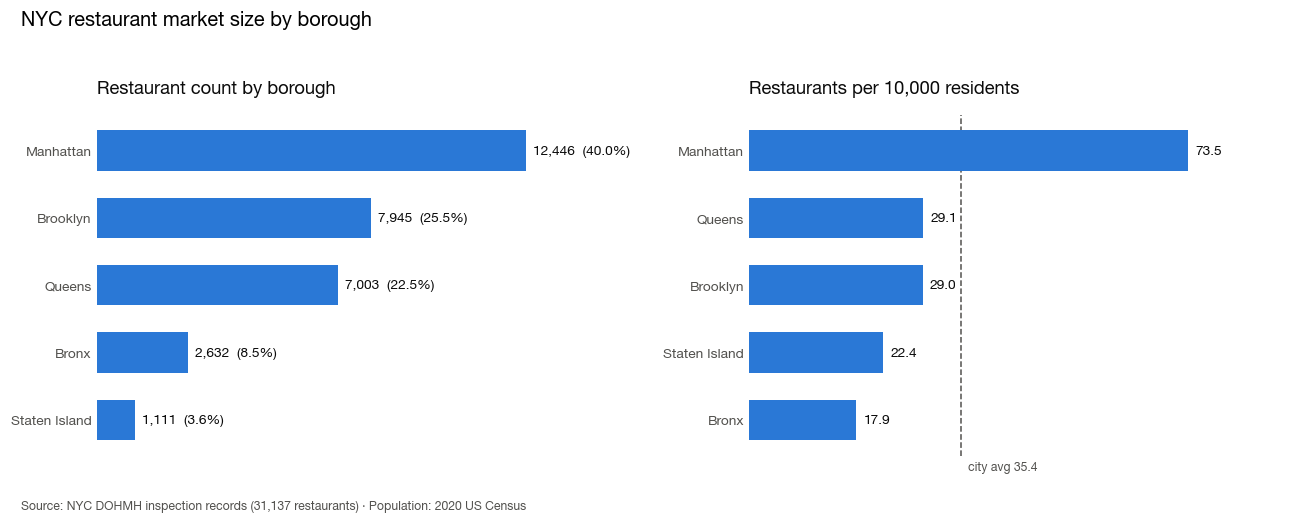

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# --- Left: absolute count ---
ax = axes[0]
d = boro_stats.sort_values("restaurants")
bars = ax.barh(d.index, d["restaurants"], color=BLUE, height=0.6)
for b, v, s in zip(bars, d["restaurants"], d["share_pct"]):
    ax.text(v + 200, b.get_y() + b.get_height() / 2, f"{v:,}  ({s}%)",
            va="center", fontsize=9, color=INK)
ax.set_title("Restaurant count by borough", loc="left")
ax.set_xlim(0, d["restaurants"].max() * 1.28)
ax.set_xticks([])
strip_axes(ax, keep=())

# --- Right: per capita ---
ax = axes[1]
d2 = boro_stats.sort_values("per_10k")
bars = ax.barh(d2.index, d2["per_10k"], color=BLUE, height=0.6)
for b, v in zip(bars, d2["per_10k"]):
    ax.text(v + 1.2, b.get_y() + b.get_height() / 2, f"{v}",
            va="center", fontsize=9, color=INK)
ax.axvline(city_avg, color=INK_SOFT, lw=1, ls="--", zorder=0)
ax.text(city_avg + 1.2, -0.75, f"city avg {city_avg:.1f}", fontsize=8,
        color=INK_SOFT, style="italic")
ax.set_title("Restaurants per 10,000 residents", loc="left")
ax.set_xlim(0, d2["per_10k"].max() * 1.25)
ax.set_xticks([])
strip_axes(ax, keep=())

fig.suptitle("NYC restaurant market size by borough", x=0.02, ha="left",
             fontsize=13, fontweight="bold", y=1.04)
fig.text(0.02, -0.04, "Source: NYC DOHMH inspection records (31,137 restaurants) · "
                      "Population: 2020 US Census", fontsize=8, color=INK_SOFT)
plt.tight_layout()
plt.savefig(FIGURES / "01_market_size_by_borough.png")
plt.show()

**Reading the chart**

Manhattan holds 12,446 restaurants, 40% of the city. But the real separation is density:
**73.5 per 10,000 residents — 2.5x Brooklyn and Queens (~29) and 4.1x the Bronx (17.9).**

One interpretation trap worth naming: Manhattan's density is inflated by commuters and
tourists, who consume restaurant capacity but are not in the resident denominator.
Conversely, the Bronx's low density could mean an underserved market *or* simply reflect
local income and dining habits — this chart cannot distinguish the two. Section 5 returns
to that question.

## 3. Citywide cuisine landscape

In [6]:
cuisine_counts = mix["cuisine"].value_counts()
top_n = 15
top_cuisines = cuisine_counts.head(top_n)

print(f"Distinct cuisines: {mix['cuisine'].nunique()}")
print(f"Top {top_n} cover {top_cuisines.sum() / len(mix):.1%} of restaurants")
print(f"Long tail: {(cuisine_counts < 50).sum()} cuisines have fewer than 50 restaurants, "
      f"totalling only {cuisine_counts[cuisine_counts < 50].sum():,}")
display(top_cuisines.head(10).to_frame("restaurants"))

Distinct cuisines: 89
Top 15 cover 73.0% of restaurants
Long tail: 42 cuisines have fewer than 50 restaurants, totalling only 789


,restaurants
cuisine,
AMERICAN,4844
CHINESE,2281
COFFEE/TEA,2207
PIZZA,1606
MEXICAN,1108
LATIN AMERICAN,1092
JAPANESE,1059
ITALIAN,999
BAKERY PRODUCTS/DESSERTS,922


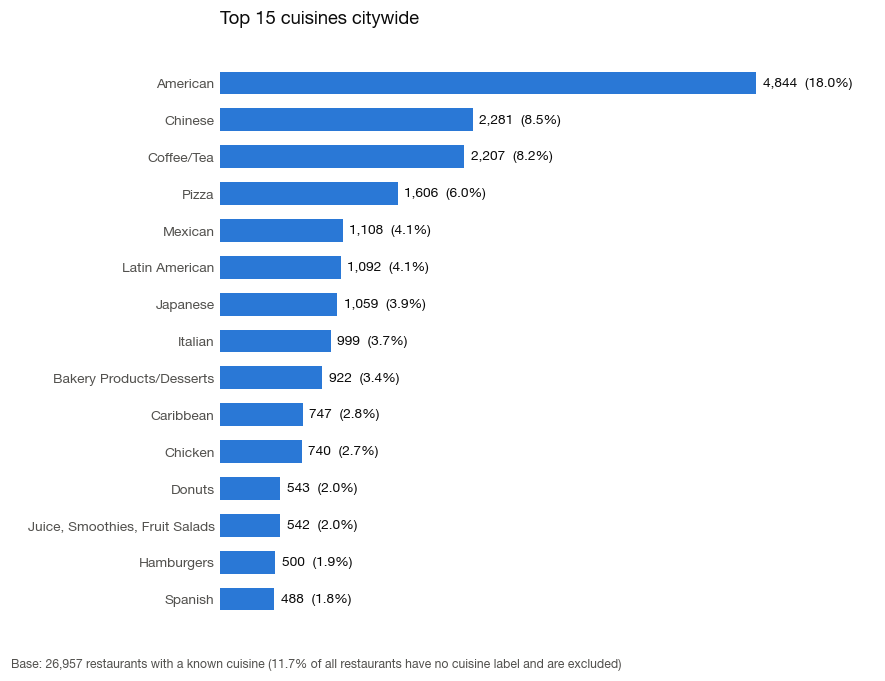

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

d = top_cuisines.sort_values()
share = d / len(mix) * 100
bars = ax.barh(range(len(d)), d.values, color=BLUE, height=0.62)
ax.set_yticks(range(len(d)))
ax.set_yticklabels([s.title() for s in d.index])

for i, (v, s) in enumerate(zip(d.values, share.values)):
    ax.text(v + 60, i, f"{v:,}  ({s:.1f}%)", va="center", fontsize=9, color=INK)

ax.set_title(f"Top {top_n} cuisines citywide", loc="left")
ax.set_xlim(0, d.max() * 1.22)
ax.set_xticks([])
strip_axes(ax, keep=())
fig.text(0.0, -0.02, f"Base: {len(mix):,} restaurants with a known cuisine "
                     "(11.7% of all restaurants have no cuisine label and are excluded)",
         fontsize=8, color=INK_SOFT)
plt.tight_layout()
plt.savefig(FIGURES / "02_top_cuisines_citywide.png")
plt.show()

**Reading the chart**

The distribution is a classic long tail: the top 15 cuisines account for ~65% of
restaurants, while 42 of the 91 cuisines have fewer than 50 locations each.

Note that `AMERICAN` (4,852) is a **catch-all category** in the DOHMH taxonomy — burger
joints, diners and ordinary bars all land there. Its lead reflects classification
granularity more than genuine consumer preference, which matters for the next section.

## 4. Borough x cuisine composition

The same cuisine occupies very different shares in different boroughs. The heatmap below
shows **each borough's internal composition**, with magnitude encoded by a single blue ramp.

In [8]:
ct = pd.crosstab(mix["cuisine"], mix["boro"])
BORO_ORDER = ["Manhattan", "Brooklyn", "Queens", "Bronx", "Staten Island"]
ct = ct[BORO_ORDER]

top12 = ct.sum(axis=1).sort_values(ascending=False).head(12).index
share_pct = (ct / ct.sum(axis=0) * 100).loc[top12]

display(share_pct.round(1))
print("\nTop-12 coverage per borough (%):")
print(share_pct.sum().round(1).to_string())

boro,Manhattan,Brooklyn,Queens,Bronx,Staten Island
cuisine,,,,,
AMERICAN,23.3,15.6,13.2,13.7,17.1
CHINESE,5.1,9.5,12.4,9.8,9.6
COFFEE/TEA,10.5,8.8,5.6,3.7,6.1
PIZZA,4.6,6.1,5.7,10.6,10.7
MEXICAN,2.8,4.8,4.3,6.7,5.9
LATIN AMERICAN,2.0,3.1,7.7,7.8,1.4
JAPANESE,5.3,3.5,3.0,1.3,4.6
ITALIAN,5.7,2.7,1.8,1.6,6.8
BAKERY PRODUCTS/DESSERTS,2.9,3.3,4.4,3.6,3.2



Top-12 coverage per borough (%):
boro
Manhattan        65.7
Brooklyn         67.2
Queens           67.2
Bronx            73.3
Staten Island    71.9


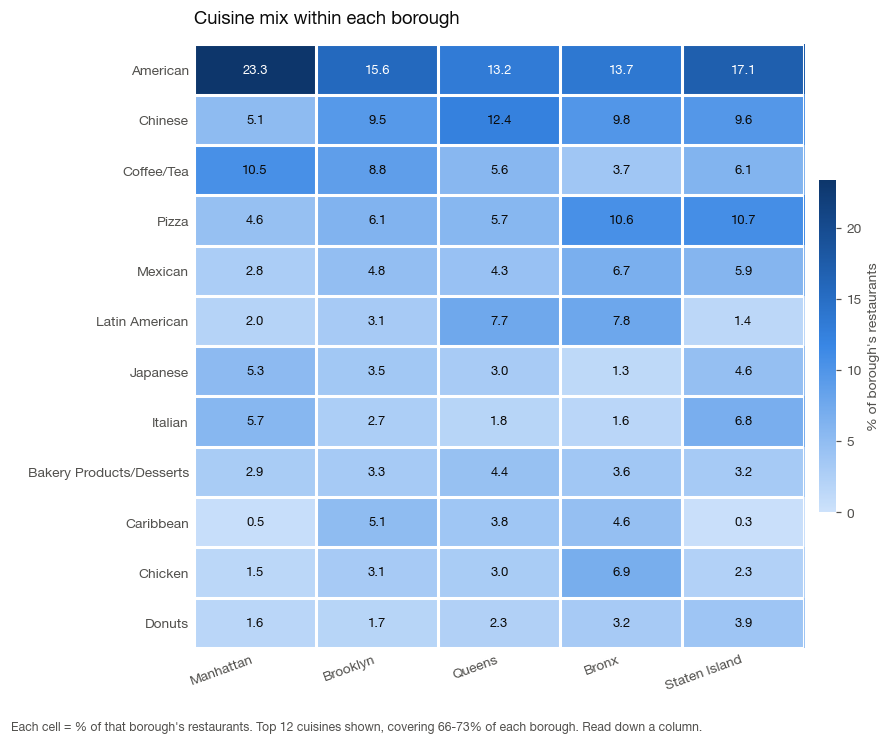

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 6.5))

data = share_pct.values
im = ax.imshow(data, cmap=CMAP_SEQ, aspect="auto", vmin=0, vmax=data.max())

ax.set_xticks(range(len(share_pct.columns)))
ax.set_xticklabels(share_pct.columns, rotation=20, ha="right")
ax.set_yticks(range(len(share_pct.index)))
ax.set_yticklabels([s.title() for s in share_pct.index])

# Label every cell; flip to white text on dark fills to hold contrast
threshold = data.max() * 0.55
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        v = data[i, j]
        ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=8.5,
                color="white" if v > threshold else INK)

# 2px surface gap between cells so the blocks never merge
ax.set_xticks(np.arange(-0.5, data.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, data.shape[0], 1), minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.tick_params(which="minor", length=0)
strip_axes(ax, keep=())

cbar = fig.colorbar(im, ax=ax, shrink=0.55, pad=0.02)
cbar.set_label("% of borough's restaurants", fontsize=9, color=INK_SOFT)
cbar.outline.set_visible(False)

ax.set_title("Cuisine mix within each borough", loc="left")
fig.text(0.0, -0.03, "Each cell = % of that borough's restaurants. Top 12 cuisines shown, "
                     "covering 66-73% of each borough. Read down a column.",
         fontsize=8, color=INK_SOFT)
plt.tight_layout()
plt.savefig(FIGURES / "03_cuisine_mix_by_borough.png")
plt.show()

**Reading the chart**

Each cell is that cuisine's share of *all* restaurants in that borough. Read down a
column and each borough's character emerges:

- **Manhattan** — American 23.3% + Coffee/Tea 10.5%: a third of the borough, the classic
  CBD pattern of fast food and coffee
- **Bronx** — Pizza 10.6%, Chinese 9.8%, Latin American 7.8%, Chicken 6.9%: value-oriented
  quick service
- **Queens** — Chinese 12.4% + Latin American 7.7%: the most ethnically concentrated dining scene
- **Staten Island** — Pizza 10.7% + Italian 6.8%: a visibly Italian-American community
- **Brooklyn** — the most balanced; even its largest category, American, is only 15.6%

But **a high share does not mean a local specialty**. American ranks first in all five
boroughs (13.2%–23.3%), so it separates nothing. Identifying genuine regional character —
and genuine gaps — needs a different metric.

## 5. Concentration: where a cuisine is over- or under-supplied

The **location quotient (LQ)** divides a cuisine's share within a borough by its share
citywide:

$$LQ = \frac{\text{cuisine's share of that borough}}{\text{cuisine's share of the whole city}}$$

- `LQ = 1` — exactly in line with the city
- `LQ > 1` — **over-represented**, a local specialty
- `LQ < 1` — **under-represented**, supplied below the citywide norm

The virtue of LQ is that it **removes the effect of borough size**: Manhattan has the most
restaurants, but that alone does not inflate its LQ for anything.

In [10]:
city_share = ct.sum(axis=1) / ct.sum().sum()
lq = (ct / ct.sum(axis=0)).div(city_share, axis=0)
lq12 = lq.loc[top12]

display(lq12.round(2))

boro,Manhattan,Brooklyn,Queens,Bronx,Staten Island
cuisine,,,,,
AMERICAN,1.30,0.87,0.73,0.76,0.95
CHINESE,0.61,1.12,1.46,1.15,1.13
COFFEE/TEA,1.28,1.07,0.69,0.45,0.74
PIZZA,0.77,1.03,0.95,1.77,1.80
MEXICAN,0.68,1.17,1.05,1.63,1.43
LATIN AMERICAN,0.48,0.77,1.89,1.93,0.36
JAPANESE,1.35,0.88,0.77,0.32,1.18
ITALIAN,1.53,0.72,0.49,0.44,1.83
BAKERY PRODUCTS/DESSERTS,0.86,0.96,1.28,1.05,0.93


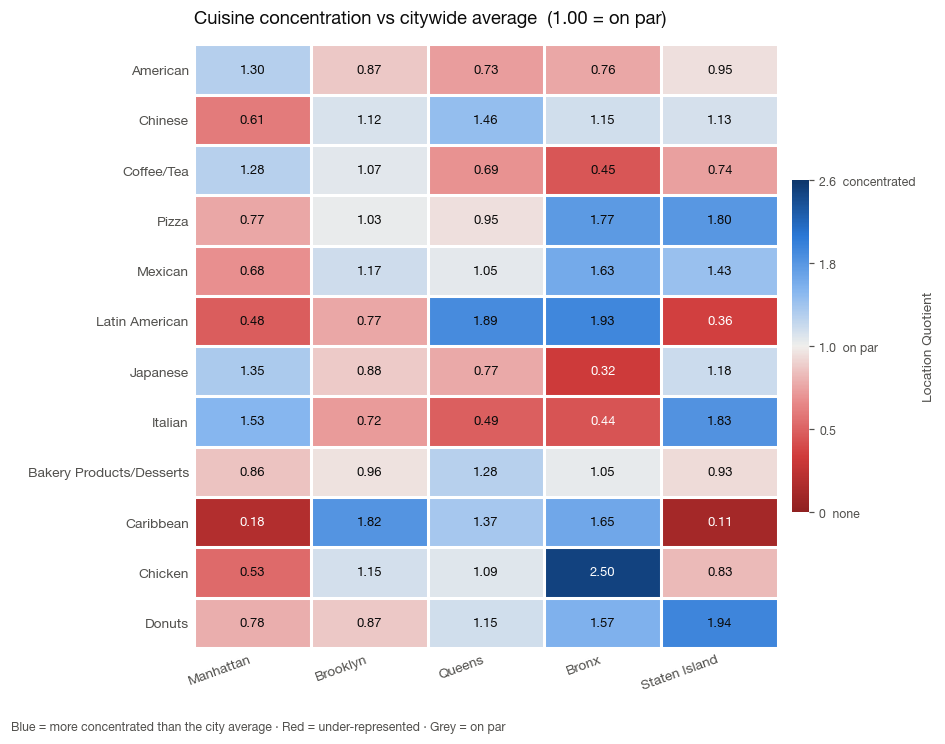

In [11]:
fig, ax = plt.subplots(figsize=(8.5, 6.5))

data = lq12.values
# Neutral grey anchored at LQ = 1; blue = over-supplied, red = under-supplied
norm = TwoSlopeNorm(vmin=0, vcenter=1.0, vmax=max(2.6, data.max()))
im = ax.imshow(data, cmap=CMAP_DIV, aspect="auto", norm=norm)

ax.set_xticks(range(len(lq12.columns)))
ax.set_xticklabels(lq12.columns, rotation=20, ha="right")
ax.set_yticks(range(len(lq12.index)))
ax.set_yticklabels([s.title() for s in lq12.index])

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        v = data[i, j]
        extreme = v < 0.45 or v > 2.0
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8.5,
                color="white" if extreme else INK)

ax.set_xticks(np.arange(-0.5, data.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, data.shape[0], 1), minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.tick_params(which="minor", length=0)
strip_axes(ax, keep=())

cbar = fig.colorbar(im, ax=ax, shrink=0.55, pad=0.02, ticks=[0, 0.5, 1.0, 1.8, 2.6])
cbar.set_label("Location Quotient", fontsize=9, color=INK_SOFT)
# Self-documenting ticks, so no extra text collides with the numbers
cbar.ax.set_yticklabels(["0  none", "0.5", "1.0  on par", "1.8", "2.6  concentrated"],
                        fontsize=8)
cbar.outline.set_visible(False)

ax.set_title("Cuisine concentration vs citywide average  (1.00 = on par)", loc="left")
fig.text(0.0, -0.03, "Blue = more concentrated than the city average · "
                     "Red = under-represented · Grey = on par",
         fontsize=8, color=INK_SOFT)
plt.tight_layout()
plt.savefig(FIGURES / "04_location_quotient.png")
plt.show()

**Reading the chart**

Same table, different metric, entirely different story:

| Borough | Over-supplied (local character) | Under-supplied |
|---|---|---|
| Bronx | Chicken **2.50**, Latin American **1.93**, Pizza **1.77** | Japanese **0.32**, Italian **0.44** |
| Staten Island | Donuts **1.94**, Italian **1.83**, Pizza **1.80** | Caribbean **0.11**, Latin American **0.36** |
| Brooklyn | Caribbean **1.82**, Mexican 1.17 | Italian 0.72, Latin American 0.77 |
| Queens | Latin American **1.89**, Chinese **1.46** | Italian 0.49, Japanese 0.77 |
| Manhattan | Italian **1.53**, Japanese **1.35**, American 1.30 | Caribbean **0.18**, Latin American 0.48 |

In section 4 American led every borough and revealed nothing. Its LQ values land between
0.73 and 1.30 — confirming it is an evenly spread catch-all with no regional signal. The
cuisines with real geographic character are Caribbean (Brooklyn 1.82 vs Staten Island
0.11, a **16x spread**) and Latin American (Queens 1.89 vs Staten Island 0.36).

## 6. Supply gaps: proven cuisines that are scarce in a borough

A low LQ alone is not interesting — a niche cuisine with 20 locations citywide being
absent somewhere means nothing commercially. What matters is **both conditions together**:

1. The cuisine is already established citywide (>= 300 locations), so the format is proven
2. Yet a given borough's LQ is below 0.35, i.e. materially under-supplied

In [12]:
MIN_CITYWIDE = 300
MAX_LQ = 0.35

established = ct[ct.sum(axis=1) >= MIN_CITYWIDE]
lq_est = (established / ct.sum(axis=0)).div(
    established.sum(axis=1) / ct.sum().sum(), axis=0
)

gaps = (
    lq_est.stack().reset_index()
    .rename(columns={"level_0": "cuisine", 0: "lq"})
)
gaps["citywide_stores"] = gaps["cuisine"].map(established.sum(axis=1))
gaps["borough_stores"] = [established.loc[r.cuisine, r.boro] for r in gaps.itertuples()]
# How many locations the borough would hold at the citywide concentration
gaps["expected_at_parity"] = (gaps["borough_stores"] / gaps["lq"]).round(0)
gaps["shortfall"] = (gaps["expected_at_parity"] - gaps["borough_stores"]).astype(int)

gaps = (
    gaps[gaps["lq"] < MAX_LQ]
    .sort_values("shortfall", ascending=False)
    .reset_index(drop=True)
)
gaps["lq"] = gaps["lq"].round(2)

print(f"Borough-cuisine combinations meeting both conditions: {len(gaps)}\n")
display(gaps[["boro", "cuisine", "borough_stores", "citywide_stores",
              "lq", "expected_at_parity", "shortfall"]])

Borough-cuisine combinations meeting both conditions: 9



,boro,cuisine,borough_stores,citywide_stores,lq,expected_at_parity,shortfall
0,Manhattan,CARIBBEAN,53,747,0.18,293.0,240
1,Brooklyn,KOREAN,37,427,0.34,109.0,72
2,Bronx,JAPANESE,30,1059,0.32,93.0,63
3,Bronx,KOREAN,3,427,0.08,38.0,35
4,Bronx,ASIAN/ASIAN FUSION,11,479,0.26,42.0,31
5,Bronx,THAI,4,355,0.13,31.0,27
6,Staten Island,CARIBBEAN,3,747,0.11,27.0,24
7,Bronx,JEWISH/KOSHER,8,339,0.27,30.0,22
8,Bronx,MEDITERRANEAN,7,322,0.25,28.0,21


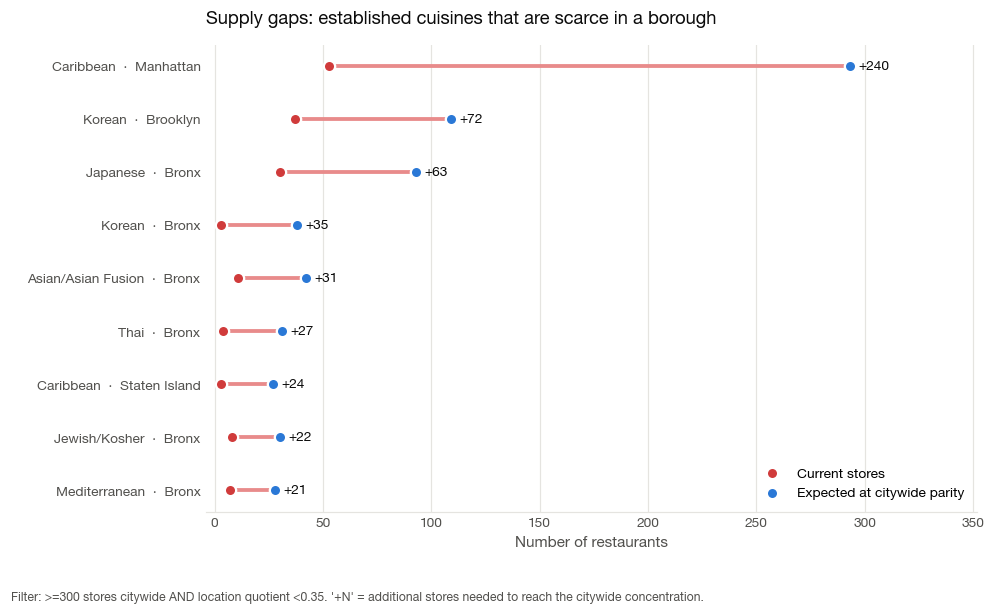

In [13]:
fig, ax = plt.subplots(figsize=(9, 5.2))

d = gaps.sort_values("shortfall").reset_index(drop=True)
labels = [f"{r.cuisine.title()}  ·  {r.boro}" for r in d.itertuples()]
y = range(len(d))

# Lollipop: the segment is the gap, the dots are current vs expected
ax.hlines(y, d["borough_stores"], d["expected_at_parity"],
          color="#e88b8b", lw=2.5, zorder=1)
ax.scatter(d["borough_stores"], y, s=55, color="#d03b3b", zorder=3,
           label="Current stores", edgecolor="white", linewidth=1.5)
ax.scatter(d["expected_at_parity"], y, s=55, color=BLUE, zorder=3,
           label="Expected at citywide parity", edgecolor="white", linewidth=1.5)

ax.set_yticks(list(y))
ax.set_yticklabels(labels)
for i, r in enumerate(d.itertuples()):
    ax.text(r.expected_at_parity + 4, i, f"+{r.shortfall}", va="center",
            fontsize=9, color=INK, fontweight="bold")

ax.set_xlabel("Number of restaurants")
ax.set_xlim(-4, d["expected_at_parity"].max() * 1.2)
ax.grid(axis="x", color=GRID, lw=0.8, zorder=0)
ax.set_axisbelow(True)
strip_axes(ax, keep=("bottom",))
ax.legend(loc="lower right", fontsize=9)

ax.set_title("Supply gaps: established cuisines that are scarce in a borough", loc="left")
fig.text(0.0, -0.06,
         f"Filter: >={MIN_CITYWIDE} stores citywide AND location quotient <{MAX_LQ}. "
         "'+N' = additional stores needed to reach the citywide concentration.",
         fontsize=8, color=INK_SOFT)
plt.tight_layout()
plt.savefig(FIGURES / "05_supply_gaps.png")
plt.show()

**Reading the chart**

Nine combinations qualify. The three largest absolute gaps:

1. **Caribbean · Manhattan** — 53 locations today; 293 at citywide parity, a shortfall of **+240**
2. **Korean · Brooklyn** — 37 today, 109 expected, **+72**
3. **Japanese · Bronx** — 30 today, 93 expected, **+63**

Ranked by severity of LQ rather than absolute size, the starkest is **Korean · Bronx**:
LQ 0.08, with just 3 locations against 427 citywide.

**The Bronx accounts for 6 of the 9 combinations** (Japanese, Korean, Asian/Asian Fusion,
Thai, Jewish/Kosher, Mediterranean), making it the borough with the least complete supply
structure in the city.

### A gap is not automatically an opportunity

This is the most misreadable result in the notebook, so it is worth stating plainly.
A low LQ has three very different causes, and **this dataset cannot tell them apart**:

1. **A genuine gap** — demand exists, nobody is serving it (the real opportunity)
2. **Different demand** — driven by local demographics, income and dining habits (not an opportunity)
3. **Failed attempts** — operators tried and closed (a warning, not an opportunity)

Caribbean in Manhattan is the cautionary case: a 240-location shortfall looks compelling,
but Manhattan's Caribbean-descended population share is far below Brooklyn's, so this gap
most likely belongs to category 2. **Separating the three requires census demographics and
opening/closing histories** — that is the next piece of work, not a conclusion available today.

## 7. Summary

### Key findings

1. **The market is concentrated in Manhattan**: 40% of all restaurants, at 73.5 per 10,000
   residents — 4.1x the Bronx (17.9) against a citywide average of 35.4
2. **Cuisine follows a long tail**: 91 cuisines, the top 15 covering 65%, and 42 with fewer
   than 50 locations
3. **Share hides character; concentration reveals it**: American leads every borough, yet
   its LQ never leaves 0.73–1.30, marking it as a catch-all label. The cuisines with real
   geographic identity are Caribbean (16x spread across boroughs) and Latin American
4. **Each borough has a distinct profile**: Manhattan as CBD fast food and coffee, Queens as
   ethnic dining, Staten Island as Italian-American, the Bronx as value quick service
5. **The Bronx has the least complete supply structure**: 6 of the 9 "established citywide
   but scarce locally" combinations

### Methodological caveats

- Cuisine shares are out of **26,957** restaurants, excluding the 11.7% with no cuisine
  label — not out of 31,222
- Density uses **2020 resident population**, which overstates Manhattan's per-capita supply
  by ignoring commuters and tourists
- The source is **health inspection records**, not a business registry — it covers only
  establishments DOHMH has inspected

### Next steps

- `03_geographic_analysis.ipynb`: map the data against `borough_boundaries.csv` and drill
  down to NTA (neighbourhood) level — borough averages mask large internal variation
- Join census demographics and income to separate genuine gaps from differing demand
- Cross-analyse `inspections.csv` to relate hygiene performance to cuisine and geography